In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
print("All imports successful")

All imports successful


In [2]:
df = pd.read_csv('../data/processed/ipo_clean.csv', parse_dates=['listing_date'])

# Sort by date — critical for time series split
df = df.sort_values('listing_date').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['listing_date'].min().date()} to {df['listing_date'].max().date()}")
df.head()

Shape: (297, 11)
Date range: 2016-01-06 to 2026-05-08


,ipo_name,listing_date,issue_price,listing_gain_pct,return_1w,return_4w,return_6w,listing_year,listing_month,listing_quarter,gain_category
0,NaN,2016-01-06,250,34.7,29.9,28.2,16.0,2016,1,1,strong
1,NaN,2016-02-08,186,-4.5,-13.8,-14.5,-20.0,2016,2,1,loss
2,NaN,2016-02-12,850,20.3,35.3,15.2,3.7,2016,2,1,strong
3,NaN,2016-02-18,321,-20.9,-33.7,-26.6,-32.1,2016,2,1,loss
4,NaN,2016-03-30,218,-21.5,-16.5,-15.5,-19.1,2016,3,1,loss


In [3]:
# Features we decided from the heatmap yesterday
# NO week returns (data leakage), NO listing_quarter (redundant)
FEATURES = ['issue_price', 'listing_year', 'listing_month']
TARGET = 'listing_gain_pct'

X = df[FEATURES]
y = df[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature stats:")
print(X.describe())

X shape: (297, 3)
y shape: (297,)

Feature stats:
       issue_price  listing_year  listing_month
count   297.000000    297.000000     297.000000
mean    396.346801   2021.565657       7.292929
std     316.579957      3.177715       3.500731
min      23.000000   2016.000000       1.000000
25%     172.000000   2018.000000       4.000000
50%     315.000000   2023.000000       8.000000
75%     506.000000   2024.000000      10.000000
max    1960.000000   2026.000000      12.000000


In [4]:
# Check for NaN in features and target
print("NaN in X:")
print(X.isnull().sum())
print(f"\nNaN in y: {y.isnull().sum()}")

# Drop any remaining NaN rows
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print(f"\nAfter dropping NaN rows:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

NaN in X:
issue_price      0
listing_year     0
listing_month    0
dtype: int64

NaN in y: 20

After dropping NaN rows:
X shape: (277, 3)
y shape: (277,)


In [5]:
# WHY TimeSeriesSplit and not regular train/test split?
# 
# Regular split: randomly picks 80% train, 20% test
# Problem: your test set might include IPOs from 2018 while train has 2024 data
# That means you're "predicting the past using the future" — that's cheating
#
# TimeSeriesSplit: always trains on older data, tests on newer data
# Fold 1: train on first 20%, test on next 20%
# Fold 2: train on first 40%, test on next 20%
# Fold 3: train on first 60%, test on next 20%
# ...and so on. Just like real life — you only know the past.

tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit — showing train/test sizes per fold:\n")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    train_dates = df['listing_date'].iloc[train_idx]
    test_dates = df['listing_date'].iloc[test_idx]
    print(f"Fold {fold+1}:")
    print(f"  Train: {len(train_idx)} IPOs | {train_dates.min().date()} → {train_dates.max().date()}")
    print(f"  Test:  {len(test_idx)} IPOs | {test_dates.min().date()} → {test_dates.max().date()}")
    print()

TimeSeriesSplit — showing train/test sizes per fold:

Fold 1:
  Train: 47 IPOs | 2016-01-06 → 2017-09-18
  Test:  46 IPOs | 2017-09-18 → 2022-04-07

Fold 2:
  Train: 93 IPOs | 2016-01-06 → 2022-04-07
  Test:  46 IPOs | 2022-04-08 → 2023-07-10

Fold 3:
  Train: 139 IPOs | 2016-01-06 → 2023-07-10
  Test:  46 IPOs | 2023-07-14 → 2023-12-27

Fold 4:
  Train: 185 IPOs | 2016-01-06 → 2023-12-27
  Test:  46 IPOs | 2023-12-28 → 2024-08-13

Fold 5:
  Train: 231 IPOs | 2016-01-06 → 2024-08-13
  Test:  46 IPOs | 2024-08-20 → 2024-12-31



In [6]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Store results per fold
fold_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    fold_results.append({'fold': fold+1, 'mae': mae, 'rmse': rmse, 'r2': r2})
    print(f"Fold {fold+1} → MAE: {mae:.2f}% | RMSE: {rmse:.2f}% | R²: {r2:.4f}")

results_df = pd.DataFrame(fold_results)
print(f"\n=== Average across all folds ===")
print(f"MAE:  {results_df['mae'].mean():.2f}% ± {results_df['mae'].std():.2f}%")
print(f"RMSE: {results_df['rmse'].mean():.2f}% ± {results_df['rmse'].std():.2f}%")
print(f"R²:   {results_df['r2'].mean():.4f} ± {results_df['r2'].std():.4f}")

Fold 1 → MAE: 19.15% | RMSE: 24.33% | R²: 0.2304
Fold 2 → MAE: 24.19% | RMSE: 31.84% | R²: -0.3793
Fold 3 → MAE: 27.22% | RMSE: 45.50% | R²: -0.0049
Fold 4 → MAE: 28.02% | RMSE: 36.37% | R²: -0.2901
Fold 5 → MAE: 31.96% | RMSE: 42.75% | R²: -0.5263

=== Average across all folds ===
MAE:  26.10% ± 4.78%
RMSE: 36.16% ± 8.50%
R²:   -0.1940 ± 0.3041


## Why this model fails and what we need

Current features: issue_price, listing_year, listing_month
Result: R² = -0.19 (worse than guessing the mean)

Missing critical features:
- GMP (Grey Market Premium) - strongest known predictor of listing gain
- QIB subscription times - institutional demand signal  
- Retail/NII subscription - retail sentiment
- Issue size - larger IPOs tend to list more conservatively

Next step: scrape subscription + GMP data and retrain.
This is standard in real ML work — garbage in, garbage out.

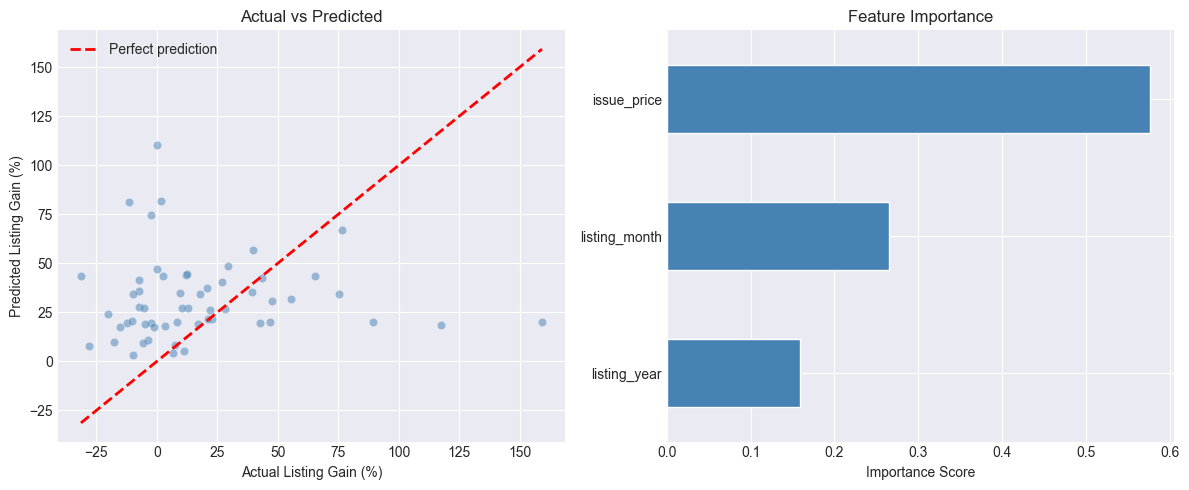

Test MAE: 31.44%
Test R²: -0.4954


In [7]:
# Train on all data except last 20%, test on last 20%
# Just for visualization purposes
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

plt.figure(figsize=(12, 5))

# Actual vs predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Listing Gain (%)')
plt.ylabel('Predicted Listing Gain (%)')
plt.title('Actual vs Predicted')
plt.legend()

# Feature importance
plt.subplot(1, 2, 2)
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/processed/plot_model_v1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.2f}%")
print(f"Test R²: {r2_score(y_test, y_pred):.4f}")

In [3]:
from scraper.gmp_scraper import scrape_subscription_data, save_subscription_raw

df_sub = scrape_subscription_data()

if df_sub is not None:
    print(f"Shape: {df_sub.shape}")
    print(f"Columns: {df_sub.columns.tolist()}")
    df_sub.head()

Starting browser...
Page loaded. Waiting for table...
Headers: ['Company', 'Issue Category', 'Opening Date', 'Issue Price (Rs.)', 'Issue Amount(Rs.Cr.)', 'QIB (X)', 'NII (X)', 'Retail (X)', 'Employees (X)', 'Others (X)', 'Shareholders (X)', 'Total (X)', 'Listing Date', 'Open Price On Listing (Rs.)', 'Close Price On Listing (Rs.)', '% Gain / Loss (Issue Price V/S Close Price On Listing)', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']


Scraping Year 2024...
  Page 1... 6 rows
  Pagination ended: Message: no such element: Unable to locate element: {"method":"css selector","selector":"li.page-item.active span.page-link"}
  (Session info: chrome=148.0.7778.217); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff6efec7de5+14895]
	chromedriver!GetHandleVerifier [0x7ff6efec7e50+14900]
	chromedriver!(No symbol) [0x7ff6efc2d5ad]
	chromed

In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import time

options = Options()
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

driver.get("https://www.chittorgarh.com/report/ipo_report_listing_day_gain/98/")

WebDriverWait(driver, 15).until(
    EC.presence_of_element_located((By.CSS_SELECTOR, "table tbody tr"))
)
time.sleep(3)

# Find all pagination-related elements
print("=== Pagination elements ===")
for tag in ["a", "button", "li", "span"]:
    elements = driver.find_elements(By.TAG_NAME, tag)
    for el in elements:
        text = el.text.strip()
        cls = el.get_attribute("class") or ""
        if any(word in text.lower() for word in ["next", "prev", "›", "»", "page"]) or "page" in cls.lower():
            print(f"<{tag}> text='{text}' class='{cls}'")

# Also print rows per page selector if any
print("\n=== Select elements ===")
selects = driver.find_elements(By.TAG_NAME, "select")
for sel in selects:
    print(f"select id='{sel.get_attribute('id')}' options={[o.text for o in sel.find_elements(By.TAG_NAME, 'option')]}")

driver.quit()
print("Done.")

=== Pagination elements ===
<button> text='« First' class='page-link'
<button> text='‹ Prev' class='page-link'
<button> text='Next ›' class='page-link'
<button> text='Last »' class='page-link'
<li> text='« First' class='page-item disabled'
<li> text='‹ Prev' class='page-item disabled'
<li> text='1' class='page-item active'
<li> text='Next ›' class='page-item '
<li> text='Last »' class='page-item '
<span> text='1' class='page-link'

=== Select elements ===
select id='' options=['Year 2027', 'Year 2026', 'Year 2025', 'Year 2024', 'Year 2023', 'Year 2022', 'Year 2021', 'Year 2020', 'Year 2019', 'Year 2018', 'Year 2017', 'Year 2016', 'Year 2015', 'Year 2014', 'Year 2013', 'Year 2012', 'Year 2011', 'Year 2010', 'Year 2009', 'Year 2008', 'Year 2007', 'Year 2006']
select id='' options=['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
select id='reportParameterDDL' options=['', '', '']
Done.


In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait, Select
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import time

options = Options()
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--window-size=1920,1080")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.chittorgarh.com/report/ipo_report_listing_day_gain/98/")

WebDriverWait(driver, 15).until(EC.presence_of_element_located((By.CSS_SELECTOR, "table tbody tr")))
time.sleep(2)

# Select year 2024 which we know has many IPOs
selects = driver.find_elements(By.TAG_NAME, "select")
for sel in selects:
    options_list = [o.text for o in sel.find_elements(By.TAG_NAME, "option")]
    if any("Year" in opt for opt in options_list):
        Select(sel).select_by_visible_text("Year 2024")
        break

time.sleep(3)

# Print ALL buttons and their full attributes
print("=== All buttons on page ===")
buttons = driver.find_elements(By.TAG_NAME, "button")
for btn in buttons:
    print(f"text='{btn.text.strip()}' | class='{btn.get_attribute('class')}' | disabled='{btn.get_attribute('disabled')}'")

# Print total row count
rows = driver.find_elements(By.CSS_SELECTOR, "table tbody tr")
print(f"\nRows on current page: {len(rows)}")

# Check if there's a rows-per-page control
print("\n=== Page info text ===")
for el in driver.find_elements(By.XPATH, "//*[contains(text(),'Showing') or contains(text(),'Total') or contains(text(),'of')]"):
    txt = el.text.strip()
    if txt and len(txt) < 100:
        print(f"  '{txt}'")

driver.quit()

=== All buttons on page ===
text='' | class='nav-item ps-md-4 ps-sm-3 pe-2 nav-link' | disabled='None'
text='' | class='dropdown-item profile-item' | disabled='None'
text='' | class='dropdown-item profile-item' | disabled='None'
text='' | class='btn btn-light py-2 px-2 d-flex justify-content-center align-items-center' | disabled='None'
text='' | class='btn btn-light py-2 px-2 d-flex justify-content-center align-items-center' | disabled='None'
text='' | class='btn btn-light py-2 px-2 d-flex justify-content-center align-items-center' | disabled='None'
text='' | class='btn btn-light py-2 px-2 d-flex justify-content-center align-items-center' | disabled='None'
text='' | class='btn btn-light py-2 px-2 d-flex justify-content-center align-items-center' | disabled='None'
text='' | class='accordion-button bg-light fw-bold' | disabled='None'
text='' | class='accordion-button collapsed bg-light fw-bold' | disabled='None'
text='' | class='accordion-button collapsed bg-light fw-bold' | disabled='No